In [4]:
!pip install pykalman

In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.graphics.tsaplots as sgt
from pykalman import KalmanFilter
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression

[*********************100%***********************]  1 of 1 completed


ADF Test Results:
kalman_returns ADF Statistic: -6.784377866359304
kalman_returns p-value: 2.4533155758644796e-09
kalman_returns Critical Values: {'1%': np.float64(-3.4342184244873657), '5%': np.float64(-2.8632486915862247), '10%': np.float64(-2.567679662838086)}
price_returns ADF Statistic: -12.119669332283001
price_returns p-value: 1.8376666464626696e-22
price_returns Critical Values: {'1%': np.float64(-3.4342161374093405), '5%': np.float64(-2.863247682032273), '10%': np.float64(-2.5676791252688496)}
obv ADF Statistic: -9.093788293048267
obv p-value: 3.7623481243457894e-15
obv Critical Values: {'1%': np.float64(-3.4342002032721437), '5%': np.float64(-2.8632406484200064), '10%': np.float64(-2.5676753800009053)}
std_dev ADF Statistic: -4.279576581883738
std_dev p-value: 0.000481811527479287
std_dev Critical Values: {'1%': np.float64(-3.4342507300744147), '5%': np.float64(-2.863262951722777), '10%': np.float64(-2.5676872561165305)}


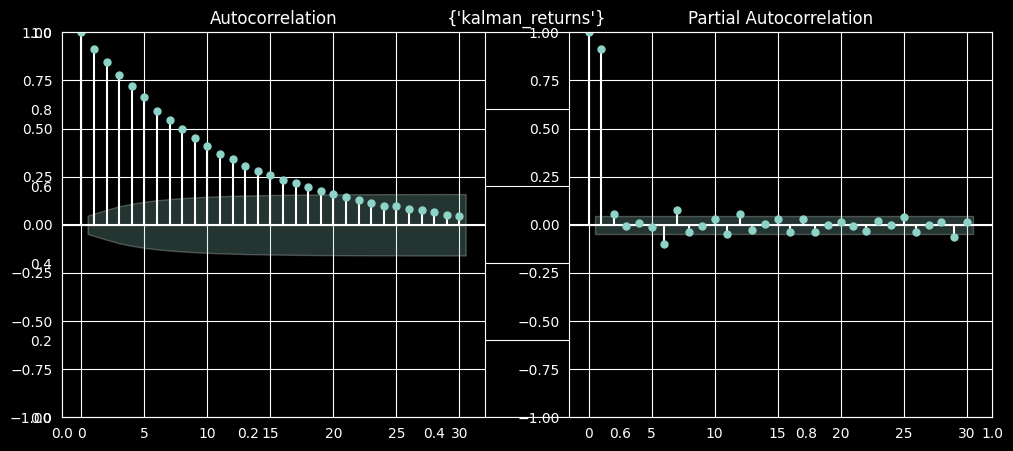

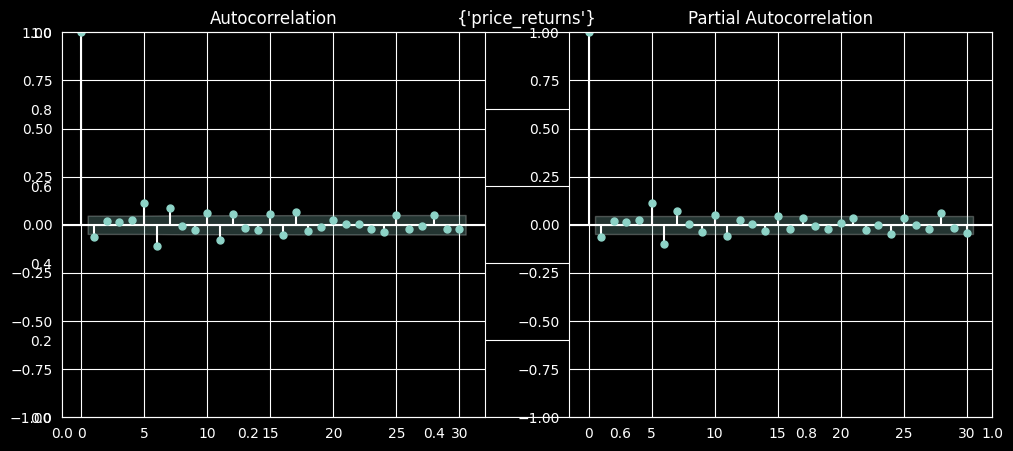

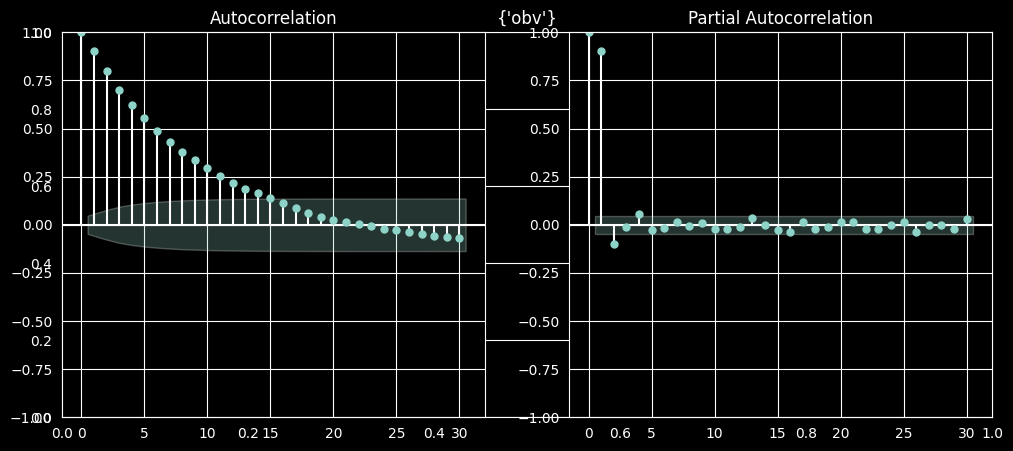

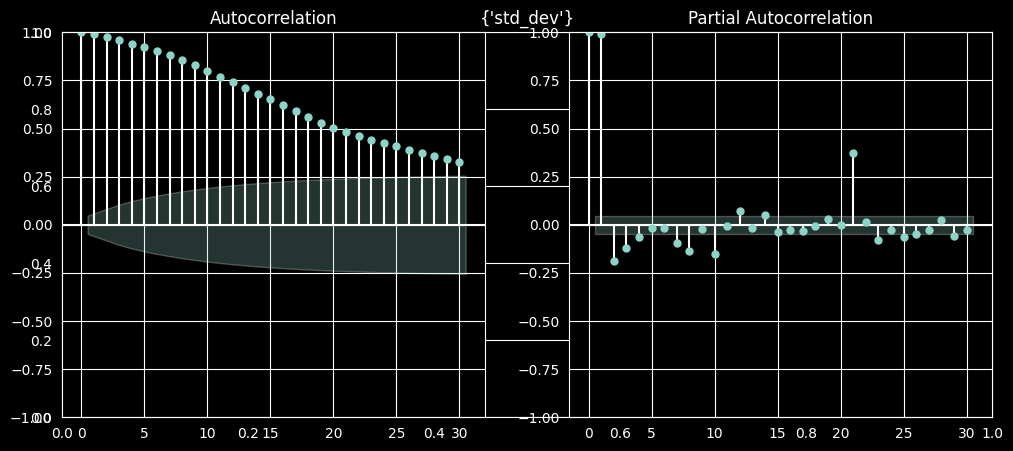

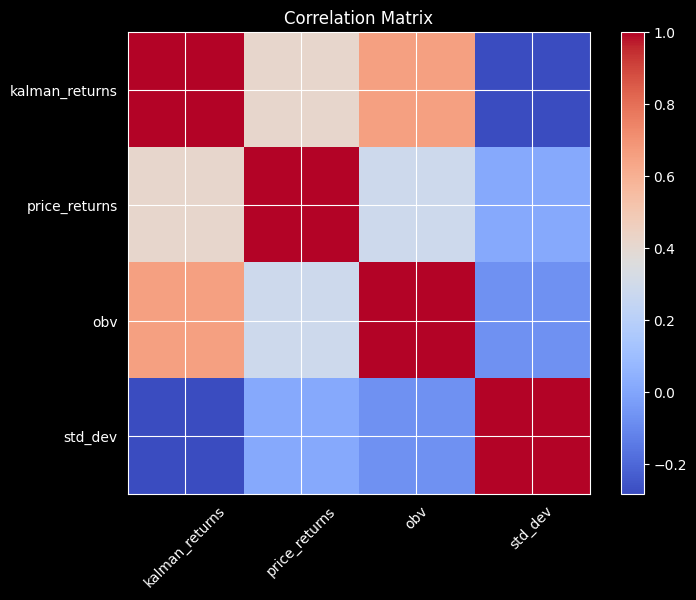

In [6]:
def calculate_obv(df):
    # df must contain 'Adj Close' and 'Volume'
    obv = [0] * len(df)
    obv[0] = df['Volume'].iloc[0]  # Start with first day's volume
    for i in range(1, len(df)):
        if df['Adj Close'].iloc[i] > df['Adj Close'].iloc[i-1]:
            obv[i] = obv[i-1] + df['Volume'].iloc[i]
        elif df['Adj Close'].iloc[i] < df['Adj Close'].iloc[i-1]:
            obv[i] = obv[i-1] - df['Volume'].iloc[i]
        else:
            obv[i] = obv[i-1]
    df['OBV'] = obv
    return df

def apply_kalman_filter(df, column='Adj Close'):
    kf = KalmanFilter(
        transition_matrices=[1],
        observation_matrices=[1],
        initial_state_mean=df[column].iloc[0],
        initial_state_covariance=1.0,
        observation_covariance=1.0,
        transition_covariance=0.01
    )
    state_means, _ = kf.filter(df[column].values)
    df['Kalman_Price'] = state_means
    return df

end = dt.date.today()
start = end - dt.timedelta(days=365*7)
df = yf.download('^NSEI',start = start,end = end,multi_level_index = False,auto_adjust = False)

# Calculate OBV
df = calculate_obv(df)

# Apply Kalman filter
df = apply_kalman_filter(df)

# Calculate returns
df['price_returns'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))
df['kalman_returns'] = np.log(df['Kalman_Price'] / df['Kalman_Price'].shift(1))
df['std_dev'] = df['price_returns'].rolling(window=20).std()

# Standardize OBV
window = 20
df['obv_rolling_mu'] = df['OBV'].rolling(window).mean()
df['obv_rolling_std'] = df['OBV'].rolling(window).std()
df['obv'] = (df['OBV'] - df['obv_rolling_mu']) / df['obv_rolling_std']

# Drop NaNs and select columns
df = df[['kalman_returns', 'price_returns', 'obv','std_dev']]
df.dropna(inplace=True)
# ADF Test
print("ADF Test Results:")
for col in df.columns:
    result = adfuller(df[col])
    print(f"{col} ADF Statistic: {result[0]}")
    print(f"{col} p-value: {result[1]}")
    print(f"{col} Critical Values: {result[4]}")

# ACF/PACF Plots
for col in df.columns:
    plt.figure(figsize=(12, 5))
    plt.title({col})
    plt.subplot(1, 2, 1)
    sgt.plot_acf(df[col], lags=30, ax=plt.gca())
    plt.subplot(1, 2, 2)
    sgt.plot_pacf(df[col], lags=30, ax=plt.gca())
    plt.show()

# Correlation Matrix
corr = df.corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation='nearest', cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [7]:
# Select only your features (X)
X = df[['kalman_returns', 'obv', 'std_dev']]
y = df['price_returns']

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

          feature       VIF
0  kalman_returns  1.822172
1             obv  1.843573
2         std_dev  1.028438


In [8]:
window = 60
preds = []
actuals = []
dates = []

# --- STEP 2: THE ROLLING LOOP ---
for i in range(window, len(y)):
    X_train = X.iloc[i-window:i]
    y_train = y.iloc[i-window:i]
    X_test = X.iloc[i:i+1]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)[0]
    preds.append(y_pred)
    actuals.append(y.iloc[i])
    dates.append(y.index[i])

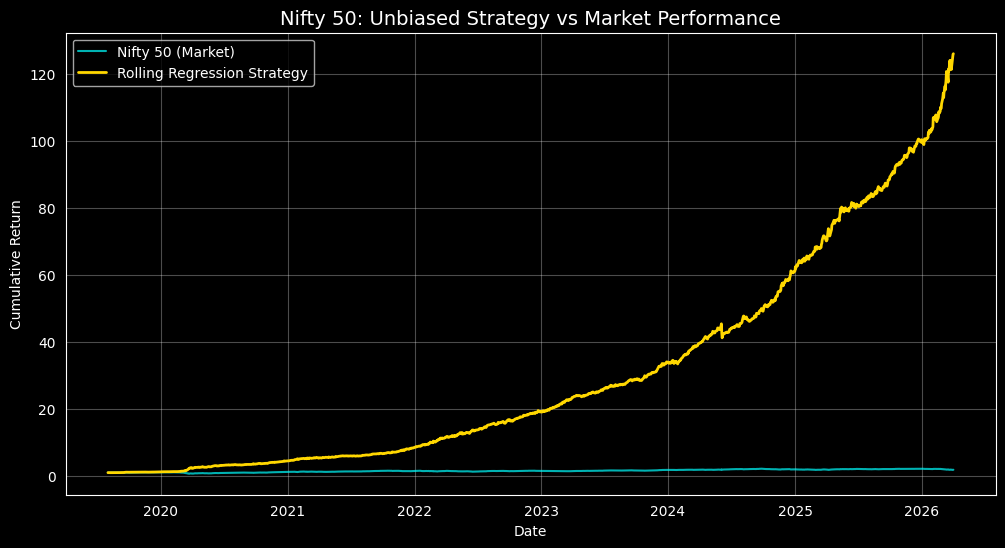

Unbiased Rolling Hit Rate: 64.07%


In [9]:
# --- STEP 3: CALCULATE STRATEGY RETURNS ---
df_strat = pd.DataFrame({'Actual': actuals, 'Predicted': preds}, index=dates)

# Signal: 1 if we predict positive, -1 if negative
df_strat['Signal'] = np.sign(df_strat['Predicted'])

# Strategy Return = Signal * Actual Market Return
df_strat['Strategy_Return'] = df_strat['Signal'] * df_strat['Actual']

# Calculate Cumulative Performance (starting from 1.0)
df_strat['Market_Cum'] = (1 + df_strat['Actual']).cumprod()
df_strat['Strategy_Cum'] = (1 + df_strat['Strategy_Return']).cumprod()

# --- STEP 4: PLOT THE EQUITY CURVE ---
plt.figure(figsize=(12, 6))
plt.plot(df_strat['Market_Cum'], label='Nifty 50 (Market)', color='cyan', alpha=0.7)
plt.plot(df_strat['Strategy_Cum'], label='Rolling Regression Strategy', color='gold', linewidth=2)
plt.title('Nifty 50: Unbiased Strategy vs Market Performance', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate the new, real Hit Rate
real_hit_rate = np.mean(np.sign(df_strat['Actual']) == np.sign(df_strat['Predicted']))
print(f"Unbiased Rolling Hit Rate: {real_hit_rate:.2%}")

In [10]:
df_strat

,Actual,Predicted,Signal,Strategy_Return,Market_Cum,Strategy_Cum
2019-08-02,0.001579,-0.009396,-1.0,-0.001579,1.001579,0.998421
2019-08-05,-0.012329,-0.009975,-1.0,0.012329,0.989231,1.010730
2019-08-06,0.007854,-0.007477,-1.0,-0.007854,0.997000,1.002792
2019-08-07,-0.008508,-0.007847,-1.0,0.008508,0.988518,1.011324
2019-08-08,0.016169,-0.003427,-1.0,-0.016169,1.004501,0.994971
...,...,...,...,...,...,...
2026-03-25,0.017052,0.008743,1.0,0.017052,1.905838,123.990236
2026-03-27,-0.021110,0.004752,1.0,-0.021110,1.865605,121.372763
2026-03-30,-0.021626,-0.004627,-1.0,0.021626,1.825259,123.997573
2026-04-01,0.015463,0.000567,1.0,0.015463,1.853484,125.914980
